In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

Text(0, 0.5, 'Feature 2')

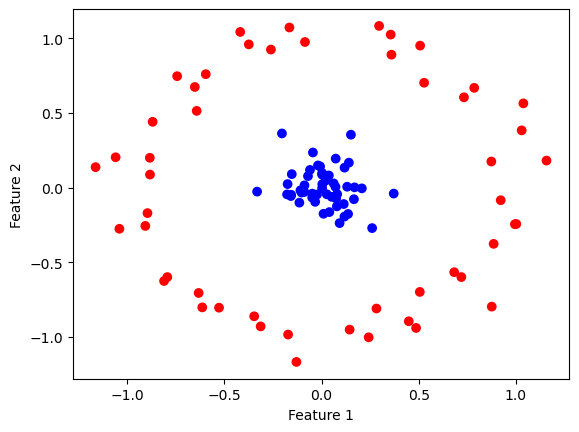

In [10]:
from sklearn.datasets import make_circles

x, y = make_circles(n_samples=100, factor=0.1, noise=0.1, random_state=42)

plt.scatter(x[:, 0], x[:, 1], c=y, cmap=ListedColormap(["red", "blue"]))
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

In [3]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [4]:
clf = SVC(kernel= 'linear')
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)


In [5]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.3

C:\Users\pawan\AppData\Local\Temp\ipykernel_10272\3780289106.py:14: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],


Text(0.5, 1.0, 'SVM (Training set)')

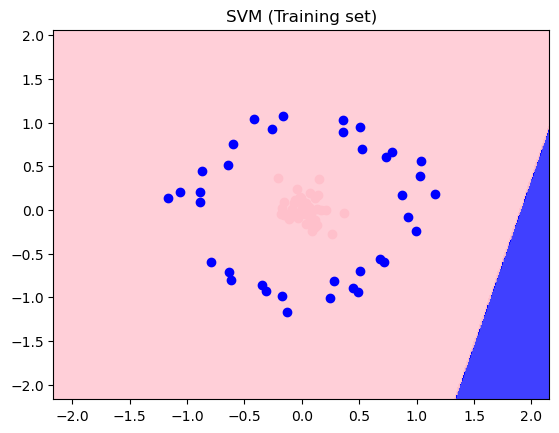

In [14]:
zero_one_color_map = ListedColormap(["red", "blue"])

def plot_decision_boundary(x, y, clf):
    x_set, y_set = x, y
    x1, x2 = np.meshgrid(np.arange(start=x_set[:, 0].min() - 1,
                                                      stop=x_set[:, 0].max() + 1, step=0.01),
                                     np.arange(start=x_set[:, 1].min() - 1,
                                               stop=x_set[:, 1].max() + 1, step=0.01))
    plt.contourf(x1, x2, clf.predict(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape),
                 alpha=0.75, cmap=zero_one_color_map)
    plt.xlim(x1.min(), x1.max())
    plt.ylim(x2.min(), x2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],
                    c=zero_one_color_map(i), label=j)
plot_decision_boundary(x_train, y_train, clf)
plt.title("SVM (Training set)")

## The Kernel Trick: RBF Kernel

The **kernel trick** allows SVM to classify non-linearly separable data by implicitly mapping the input features into a higher-dimensional space where they become linearly separable.

The **RBF (Radial Basis Function)** kernel computes similarity between points without explicitly computing the transformation:

$$K(x, x') = \exp(-\gamma ||x - x'||^2)$$

This creates a non-linear decision boundary in the original feature space.

In [15]:
# Train SVM with RBF kernel
clf_rbf = SVC(kernel='rbf', gamma=1.0, random_state=42)
clf_rbf.fit(x_train, y_train)
y_pred_rbf = clf_rbf.predict(x_test)
print(f'RBF Kernel Accuracy: {accuracy_score(y_test, y_pred_rbf):.4f}')

RBF Kernel Accuracy: 1.0000


C:\Users\pawan\AppData\Local\Temp\ipykernel_10272\3521038511.py:14: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],


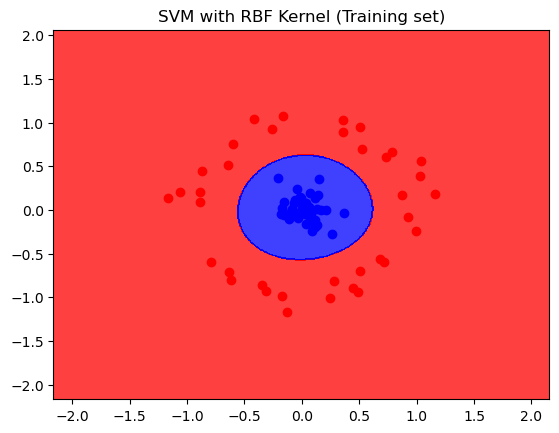

In [16]:
zero_one_color_map = ListedColormap(['red', 'blue'])

def plot_decision_boundary(x, y, clf, title='SVM'):
    x_set, y_set = x, y
    x1, x2 = np.meshgrid(np.arange(start=x_set[:, 0].min() - 1,
                                                      stop=x_set[:, 0].max() + 1, step=0.01),
                                     np.arange(start=x_set[:, 1].min() - 1,
                                               stop=x_set[:, 1].max() + 1, step=0.01))
    plt.contourf(x1, x2, clf.predict(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape),
                 alpha=0.75, cmap=zero_one_color_map)
    plt.xlim(x1.min(), x1.max())
    plt.ylim(x2.min(), x2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],
                    c=zero_one_color_map(i), label=j)
    plt.title(title)

plot_decision_boundary(x_train, y_train, clf_rbf, title='SVM with RBF Kernel (Training set)')
plt.show()

## Comparison: Linear vs RBF Kernel

Notice how the **linear kernel** creates a straight-line decision boundary, while the **RBF kernel** creates a curved boundary that can separate the circular data pattern.

C:\Users\pawan\AppData\Local\Temp\ipykernel_10272\2230978052.py:13: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1], c=zero_one_color_map(i), label=j)
C:\Users\pawan\AppData\Local\Temp\ipykernel_10272\2230978052.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1], c=zero_one_color_map(i), label=j)


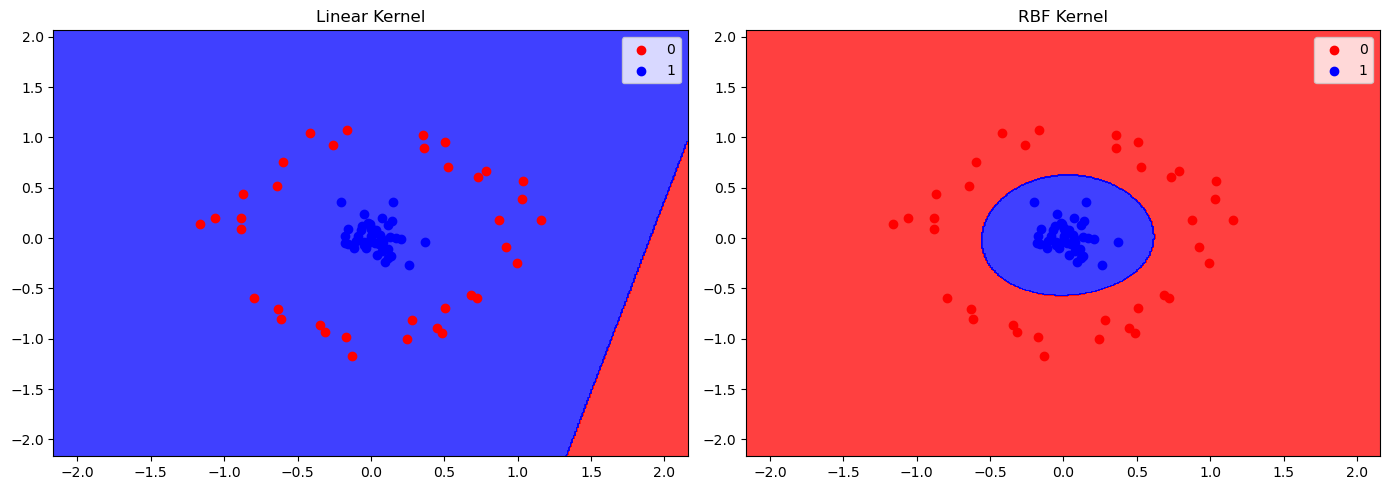

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear kernel
ax = axes[0]
x_set, y_set = x_train, y_train
x1, x2 = np.meshgrid(np.arange(start=x_set[:, 0].min() - 1, stop=x_set[:, 0].max() + 1, step=0.01),
                     np.arange(start=x_set[:, 1].min() - 1, stop=x_set[:, 1].max() + 1, step=0.01))
ax.contourf(x1, x2, clf.predict(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape),
            alpha=0.75, cmap=zero_one_color_map)
ax.set_xlim(x1.min(), x1.max())
ax.set_ylim(x2.min(), x2.max())
for i, j in enumerate(np.unique(y_set)):
    ax.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1], c=zero_one_color_map(i), label=j)
ax.set_title('Linear Kernel')
ax.legend()

# RBF kernel
ax = axes[1]
ax.contourf(x1, x2, clf_rbf.predict(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape),
            alpha=0.75, cmap=zero_one_color_map)
ax.set_xlim(x1.min(), x1.max())
ax.set_ylim(x2.min(), x2.max())
for i, j in enumerate(np.unique(y_set)):
    ax.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1], c=zero_one_color_map(i), label=j)
ax.set_title('RBF Kernel')
ax.legend()

plt.tight_layout()
plt.show()

## Effect of Gamma Parameter

The `gamma` parameter controls the influence of a single training example:
- **Low gamma**: Far points are considered similar (smoother boundary)
- **High gamma**: Only close points are considered similar (complex boundary, risk of overfitting)

C:\Users\pawan\AppData\Local\Temp\ipykernel_10272\3309978873.py:16: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1], c=zero_one_color_map(i), label=j)
C:\Users\pawan\AppData\Local\Temp\ipykernel_10272\3309978873.py:16: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1], c=zero_one_color_map(i), label=j)
C:\Users\pawan\AppData

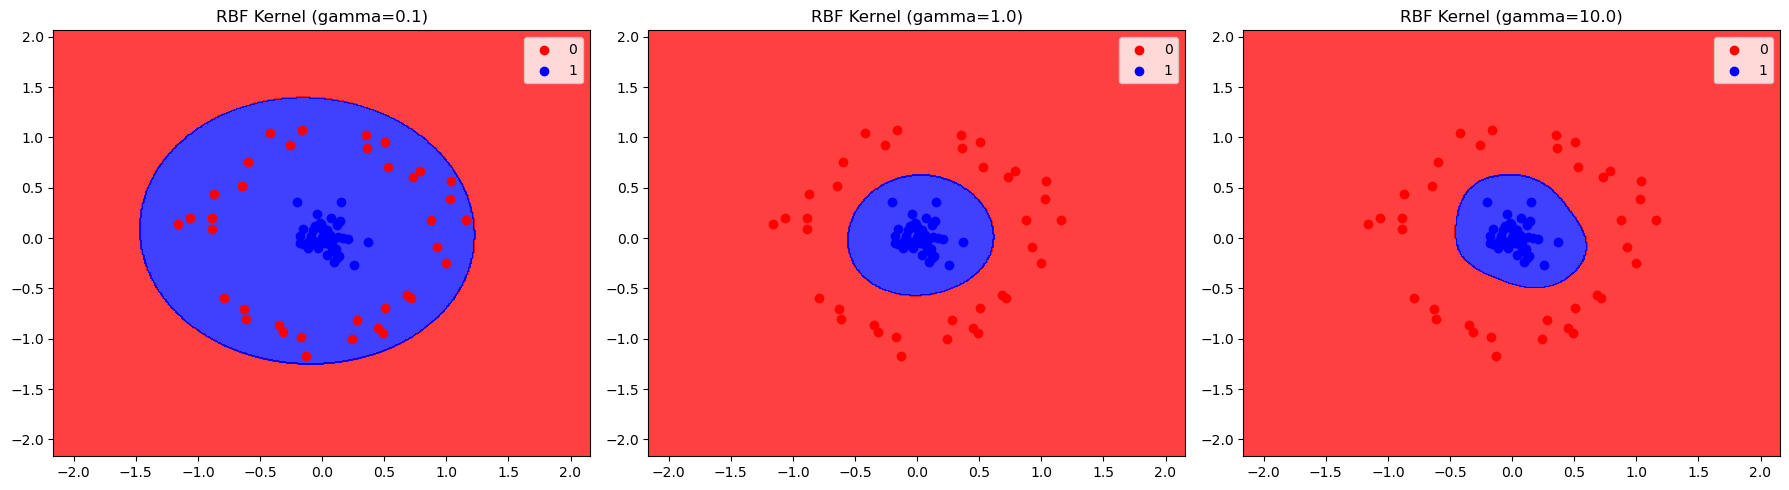

In [18]:
gammas = [0.1, 1.0, 10.0]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, gamma in zip(axes, gammas):
    clf_g = SVC(kernel='rbf', gamma=gamma, random_state=42)
    clf_g.fit(x_train, y_train)
    
    x_set, y_set = x_train, y_train
    x1, x2 = np.meshgrid(np.arange(start=x_set[:, 0].min() - 1, stop=x_set[:, 0].max() + 1, step=0.01),
                         np.arange(start=x_set[:, 1].min() - 1, stop=x_set[:, 1].max() + 1, step=0.01))
    ax.contourf(x1, x2, clf_g.predict(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape),
                alpha=0.75, cmap=zero_one_color_map)
    ax.set_xlim(x1.min(), x1.max())
    ax.set_ylim(x2.min(), x2.max())
    for i, j in enumerate(np.unique(y_set)):
        ax.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1], c=zero_one_color_map(i), label=j)
    ax.set_title(f'RBF Kernel (gamma={gamma})')
    ax.legend()

plt.tight_layout()
plt.show()

## 3D Visualization of the RBF Kernel Trick

The RBF kernel implicitly maps data into a higher-dimensional space. We can approximate this by using the **distance from support vectors** as the z-axis, showing how non-linearly separable 2D data becomes separable in 3D.

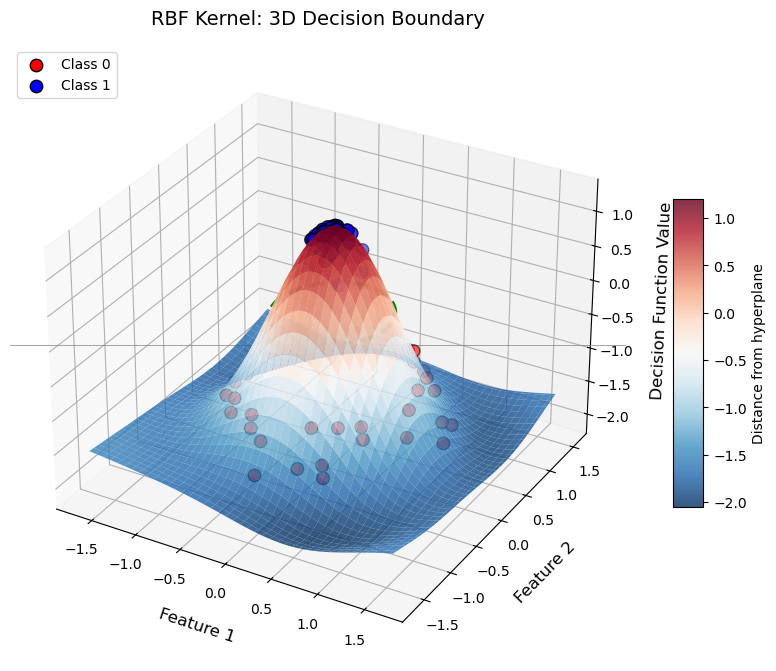

In [19]:
# Create meshgrid for surface plot
x1, x2 = np.meshgrid(
    np.arange(start=x_train[:, 0].min() - 0.5, stop=x_train[:, 0].max() + 0.5, step=0.02),
    np.arange(start=x_train[:, 1].min() - 0.5, stop=x_train[:, 1].max() + 0.5, step=0.02)
)

# Get decision function values (distance from hyperplane)
Z = clf_rbf.decision_function(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape)

# 3D surface plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot surface colored by class
surf = ax.plot_surface(x1, x2, Z, cmap='RdBu_r', alpha=0.8, edgecolor='none')

# Plot training points on the surface
for i, j in enumerate(np.unique(y_train)):
    mask = y_train == j
    z_vals = clf_rbf.decision_function(x_train[mask])
    ax.scatter(x_train[mask, 0], x_train[mask, 1], z_vals,
               c='red' if j == 0 else 'blue', s=80, edgecolors='black',
               label=f'Class {j}', depthshade=True)

# Add zero plane (decision boundary)
ax.contour(x1, x2, Z, levels=[0], colors='green', linewidths=3, linestyles='--')
ax.axhline(0, color='gray', linewidth=0.5)

ax.set_xlabel('Feature 1', fontsize=12, labelpad=10)
ax.set_ylabel('Feature 2', fontsize=12, labelpad=10)
ax.set_zlabel('Decision Function Value', fontsize=12, labelpad=10)
ax.set_title('RBF Kernel: 3D Decision Boundary', fontsize=14, pad=15)
ax.legend(loc='upper left')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Distance from hyperplane')
plt.show()

## 3D Projection View

Looking at the same surface from above, we can see how the decision boundary (green dashed line) perfectly separates the two classes in the transformed space.

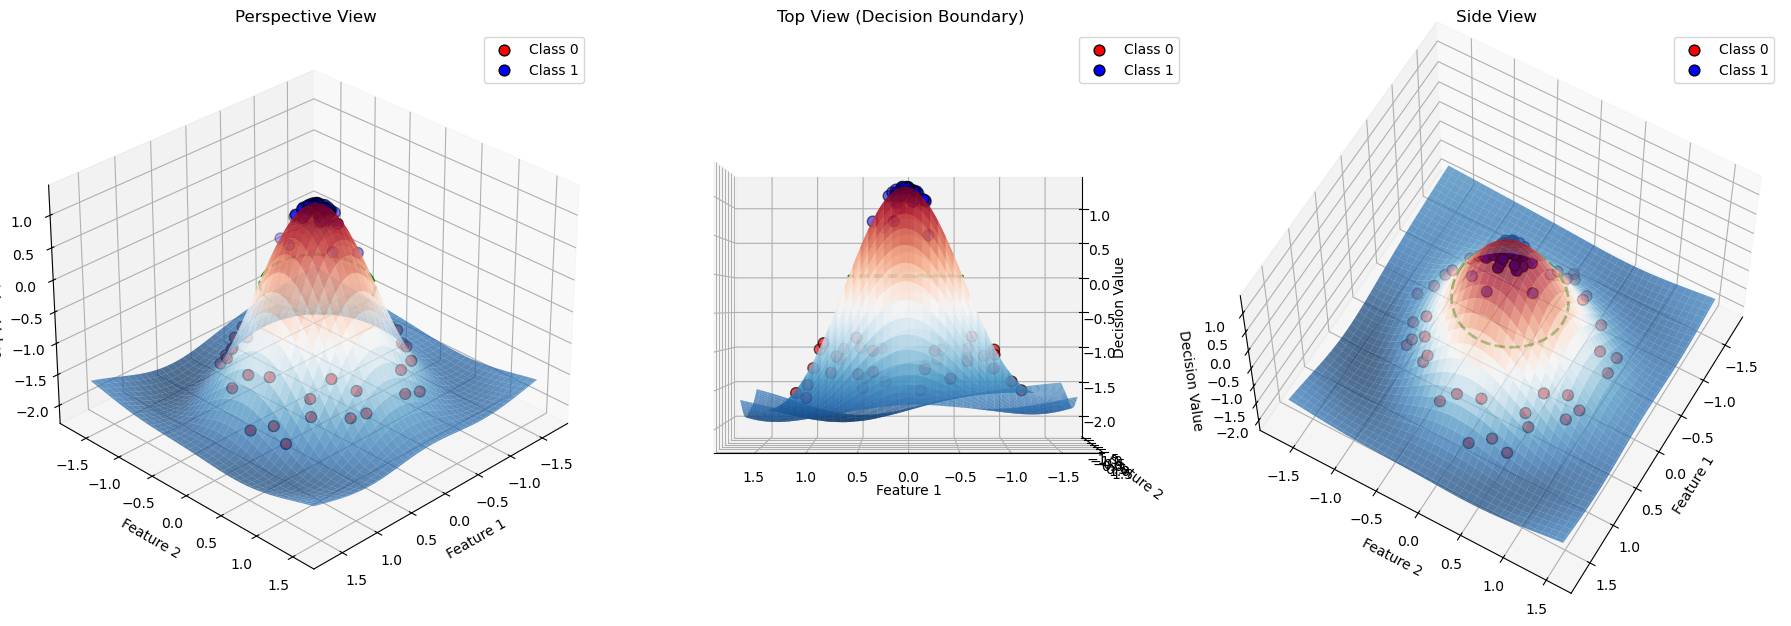

In [20]:
fig = plt.figure(figsize=(18, 6))

angles = [(30, 45), (0, 90), (60, 30)]
titles = ['Perspective View', 'Top View (Decision Boundary)', 'Side View']

for idx, (elev, azim) in enumerate(angles):
    ax = fig.add_subplot(1, 3, idx + 1, projection='3d')
    
    surf = ax.plot_surface(x1, x2, Z, cmap='RdBu_r', alpha=0.7, edgecolor='none')
    
    for i, j in enumerate(np.unique(y_train)):
        mask = y_train == j
        z_vals = clf_rbf.decision_function(x_train[mask])
        ax.scatter(x_train[mask, 0], x_train[mask, 1], z_vals,
                   c='red' if j == 0 else 'blue', s=60, edgecolors='black',
                   label=f'Class {j}')
    
    ax.contour(x1, x2, Z, levels=[0], colors='green', linewidths=2, linestyles='--')
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_zlabel('Decision Value')
    ax.set_title(titles[idx])
    ax.legend()

plt.tight_layout()
plt.show()